<a href="https://colab.research.google.com/github/camilo299restrepo/Integracion-de-Datos-y-Prospectiva/blob/main/Reto_2_Integraci%C3%B3n_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integración de Datos – Teoría de la Credibilidad**

Una FINTECH desea llevar a cabo un proceso de integración de datos con el propósito de analizar el riesgo operacional asociado a los fallos tecnológicos, para lo cual empleará diferentes métodos de integración de datos.

Para la integración de datos se plantea:

- Llevar a cabo la caracterización de la distribución agregada de pérdidas para las bases de datos de integración, utilizando métricas de tendencia central y dispersión.

- Estimar la Credibilidad de la base de datos externa con respecto a la base de datos interna.

- Integrar ambas bases de datos y realizar la caracterización de la distribución agregada de pérdidas posterior al proceso de integración.

- Para el enriquecimiento de las bases de datos, se utilizará el Método de Montecarlo, el cual se fundamenta en la estructura de una variable aleatoria construida a partir de su histograma de frecuencias.

- Aplicar la Teoría de la Credibilidad como un método para determinar la afinidad entre las bases de datos, de acuerdo con sus medidas de tendencia central y dispersión.

**Bases de datos utilizadas:**

- 1. FallasTecnológicas (2).xlsx

- IL2. AdmonEjecProcesos.xlsx


0. Cargar las librerías de trabajo

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns #Esta libreria para el trabajo estadístico
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Se procede con la clusterización estadística. La clusterización estadística esta definida por el Histograma de Frecuencias.

In [14]:
def caracterizacion(LDA):

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("Pérdida (KUSD)")
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(LDA,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  df.head(10)

  #Se procede con la estimación de la media
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  return u,sigma,Cas,Kur,df

2. Se cargan los archivos de trabajo

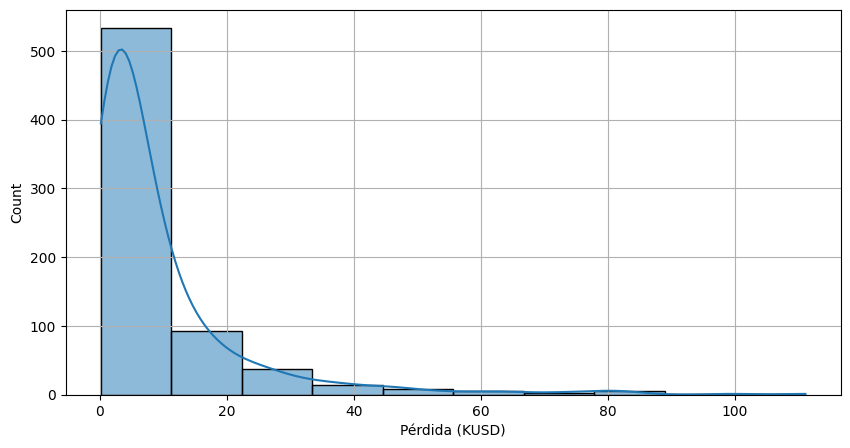

El número de datos por intervalo es:
[533  93  37  14   9   5   3   5   1   1]
Los intervalos inferiores:
[ 0.1423  11.23637 22.33044 33.42451 44.51858 55.61265 66.70672 77.80079
 88.89486 99.98893]
Los intervalos superiores:
[ 11.23637  22.33044  33.42451  44.51858  55.61265  66.70672  77.80079
  88.89486  99.98893 111.083  ]
La media de los datos observados es: 11.07019634094151
El coeficiente de asimetria es: 3.5824155186772604


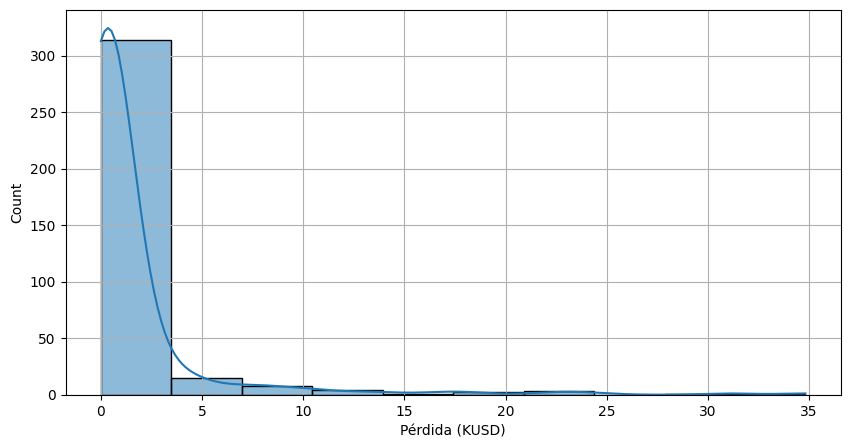

El número de datos por intervalo es:
[314  15   8   4   1   2   3   0   1   1]
Los intervalos inferiores:
[ 0.          3.48221562  6.96443124 10.44664686 13.92886248 17.4110781
 20.89329372 24.37550933 27.85772495 31.33994057]
Los intervalos superiores:
[ 3.48221562  6.96443124 10.44664686 13.92886248 17.4110781  20.89329372
 24.37550933 27.85772495 31.33994057 34.82215619]
La media de los datos externos es: 2.659055766504145
El coeficiente de asimetria es: 5.305045914196857
La credibilidad de la Base de Datos es: 0.010604763259661198
Las perdidas asumibles son: 2.748253921039784


In [15]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#1. Aqui se carga la base de datos interna (Datos Obervados)
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
nxl='/content/drive/MyDrive/Integración de datos y prospectiva/1. FallasTecnológicas (2).xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
#XDB.head(10)

#Procedemos con la construcción de la distribución agregada de las pérdidas
# Fix: Skip the first row (header) and convert to numeric
Freq=pd.to_numeric(XDB.iloc[1:,1])
Sev=pd.to_numeric(XDB.iloc[1:,2])
LDA=Freq*Sev

#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#2. Se procede con la carga de la base de datos (Datos Externos - HAPAG Lloyd)
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
nxle='/content/drive/MyDrive/Integración de datos y prospectiva/IL2. AdmonEjecProcesos.xlsx'
XDBe = pd.read_excel(nxle,sheet_name=0)
#XDBe.head(10)

# Fix: Skip the first row (header) and convert to numeric
# Correcting column indices for Freqe and Seve based on XDBe DataFrame structure.
# 'Transacciones Fallidas' is at index 1, 'Valor Generado (millones)' is at index 2.
Freqe=pd.to_numeric(XDBe.iloc[1:,1])
Seve=pd.to_numeric(XDBe.iloc[1:,2])
LDAe=Freqe*Seve

#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#3. Comparación Estadística (Media, Varianza, Desviación, Asimetriía, Kurtosis)
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#3.1. Bases de Datos Observados (EVERGREEN)
uo, sigmao, Caso, Kurto, dfo=caracterizacion(LDA)
print("La media de los datos observados es:", uo)
print("El coeficiente de asimetria es:", Caso)

#3.2. Bases de Datos Externas (Hapag Lloyd)
ue, sigmae, Case, Kurte, dfe = caracterizacion(LDAe)
print("La media de los datos externos es:", ue)
print("El coeficiente de asimetria es:", Case)

#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#4. Teoria de Credibilidad
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#4.1. Media Hipotetica
NDo = len(LDA); NDe = len(LDAe) #Para saber la inercia de los datos
uhat = (NDo*uo+NDe*ue)/(NDo+NDe)

#4.2. EPV: Valor Esperado de la Varianza
EPV = (NDo*sigmao**2 + NDe*sigmae**2)/(NDo+NDe) # Determinar la varianza conjunta de los datos

#4.3. VHM: Varianza Hipotetica de la Media
VHM = ((NDo*uo**2 + NDe*ue**2)/(NDo+NDe))-uhat**2

#4.4. Factor de Credibilidad
fc = EPV / VHM

#4.5. Credibilidad de la Base de Datos
Cr = 1-(NDo/(NDo+fc))
print("La credibilidad de la Base de Datos es:", Cr) #Evaluamos la credibilidad de la base de datos externa pues es sabido que confiamos en nuestros propios datos
#La credibilidad empieza a ser buena del 75%+

#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#5. Parametro de Riesgo
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''

#5.1. Perdidas Asumibles (Media: Franquicia)
PEs = Cr * uo + (1-Cr) * ue
print("Las perdidas asumibles son:", PEs)

**Análisis de Credibilidad**

A partir de las bases de datos analizadas, se observa que la media de las pérdidas de la base interna (uo = 11.07) es significativamente mayor que la de la base externa (ue = 2.66), lo que evidencia diferencias relevantes en el comportamiento de las pérdidas asociadas a los fallos tecnológicos. En ambas bases se presenta una distribución altamente asimétrica hacia la derecha, con mayor concentración de pérdidas de baja magnitud, siendo esta asimetría más marcada en la base externa (Caso = 3.58, Case = 5.31).

Debido a las diferencias en las medidas de tendencia central y dispersión, el coeficiente de credibilidad obtenido es bajo, cercano al 1%, lo que indica una reducida afinidad estadística entre ambas bases de datos. En consecuencia, la información externa aporta un peso limitado en el proceso de integración de datos.

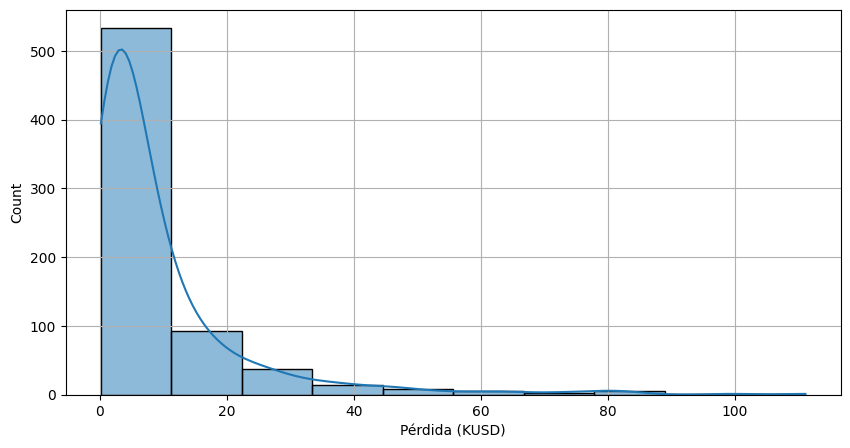

El número de datos por intervalo es:
[533  93  37  14   9   5   3   5   1   1]
Los intervalos inferiores:
[ 0.1423  11.23637 22.33044 33.42451 44.51858 55.61265 66.70672 77.80079
 88.89486 99.98893]
Los intervalos superiores:
[ 11.23637  22.33044  33.42451  44.51858  55.61265  66.70672  77.80079
  88.89486  99.98893 111.083  ]


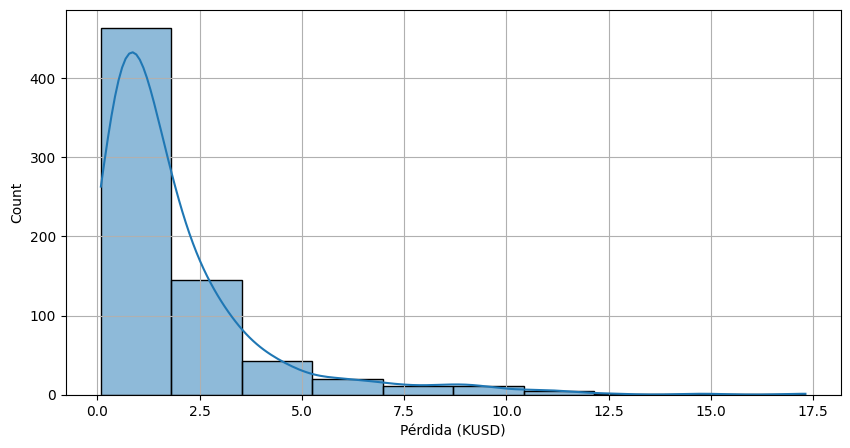

El número de datos por intervalo es:
[463 145  43  20  11  11   5   1   1   1]
Los intervalos inferiores:
[ 0.0842   1.80707  3.52994  5.25281  6.97568  8.69855 10.42142 12.14429
 13.86716 15.59003]
Los intervalos superiores:
[ 1.80707  3.52994  5.25281  6.97568  8.69855 10.42142 12.14429 13.86716
 15.59003 17.3129 ]


In [11]:
#Se procede con la estimación de las propiedades estadísticas
p1,p2,p3,p4,df=caracterizacion(LDA)

#Ahora se puede obtener las propiedades de la variable severidad
p1,p2,p3,p4,df=caracterizacion(Sev)

3. Se calcular las métricas estadísticas de tendencia central y dispersión: Media, Desviación, Asimetría y Kurtosis

In [12]:
u=np.mean(LDA)
var=np.var(LDA)
sigma=np.std(LDA) # Corrected: Calculate standard deviation of LDA

T2=np.column_stack((u,var,sigma))
df2=pd.DataFrame(T2,columns=['Media','Varianza','Desviacion'])
df2.head(1)

,Media,Varianza,Desviacion
0,9.451113,187.894776,13.707472


In [13]:
from scipy.stats import skew, kurtosis

# Calculate skewness
lda_skew = skew(LDA)

# Calculate kurtosis
lda_kurtosis = kurtosis(LDA)

# Optionally, add to the DataFrame with other metrics
df2_temp = df2.copy()
df2_temp['Asimetria'] = lda_skew
df2_temp['Kurtosis'] = lda_kurtosis

display(df2_temp)

,Media,Varianza,Desviacion,Asimetria,Kurtosis
0,9.451113,187.894776,13.707472,3.34836,14.167714


**Análisis de Resultados**

A partir de las métricas de tendencia central y dispersión, se observa que las pérdidas presentan una alta concentración de valores por debajo de la media (9.45), lo cual se evidencia en el coeficiente de asimetría positivo (3.35), superior a la unidad. Esto indica que, en general, las pérdidas asociadas a los fallos tecnológicos corresponden a eventos de baja magnitud, mientras que las pérdidas más elevadas ocurren de forma ocasional.

Por su parte, el coeficiente de curtosis (14.17) muestra una distribución altamente concentrada alrededor de la media, con presencia de valores extremos, lo que confirma el carácter esporádico de pérdidas severas. En conjunto, estos resultados refuerzan que el comportamiento de las pérdidas está dominado por pérdidas esperadas y de menor impacto económico.